In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [36]:
df= pd.read_csv('Churn_Modelling.csv')

In [37]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [38]:
df.shape

(10000, 14)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [40]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [41]:
df.duplicated().sum()

np.int64(0)

In [45]:
df.drop(['RowNumber','CustomerId','Surname'],axis=1,inplace=True)

In [46]:
df.head(2)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0


In [47]:
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')

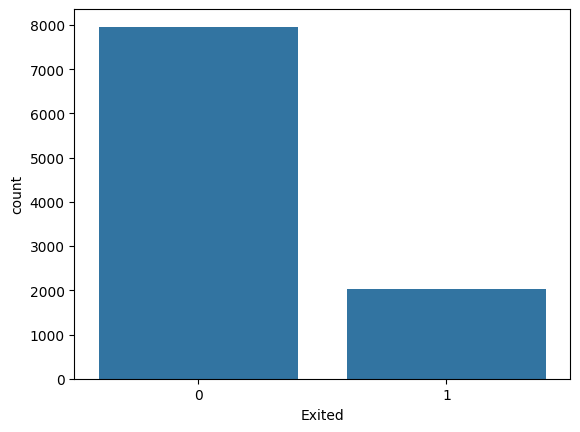

In [48]:
#Churn distribution
sns.countplot(x='Exited', data=df)
plt.show()

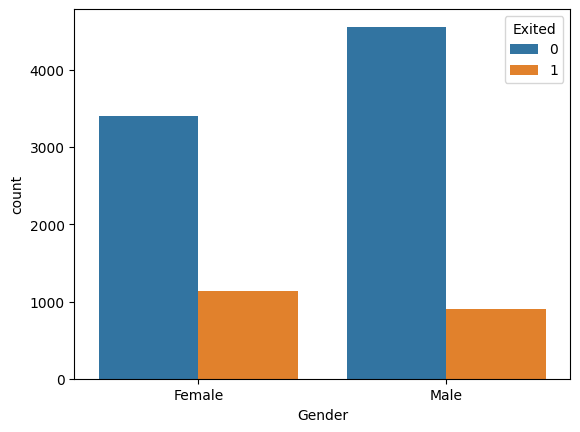

In [49]:
#Gender vs churn
sns.countplot(x='Gender', hue='Exited', data=df)
plt.show()


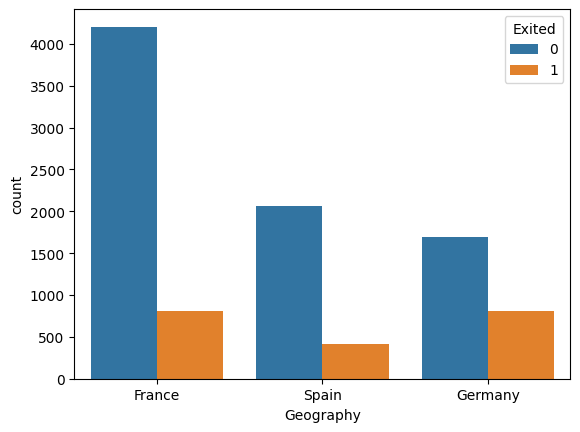

In [50]:
#Geography vs churn
sns.countplot(x='Geography', hue='Exited', data=df)
plt.show()

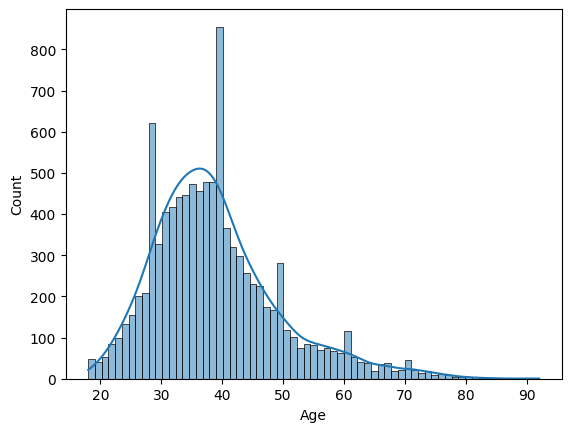

In [51]:
#Age distribution
sns.histplot(df['Age'], kde=True)
plt.show()

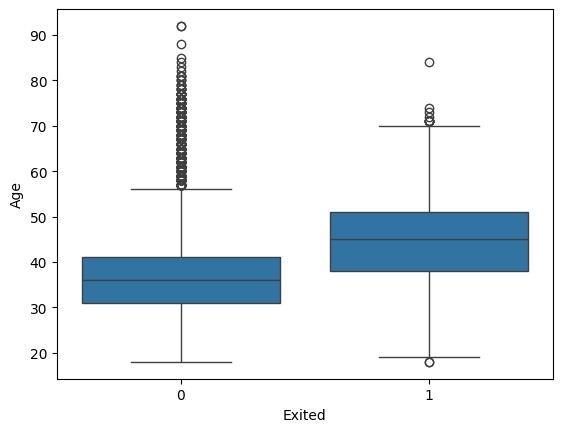

In [54]:
#age vs churn
sns.boxplot(x='Exited', y='Age', data=df)
plt.show()

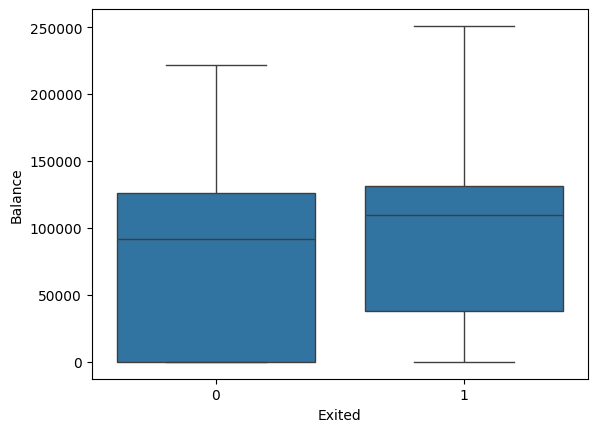

In [55]:
#balance vs churn
sns.boxplot(x='Exited', y='Balance', data=df)
plt.show()

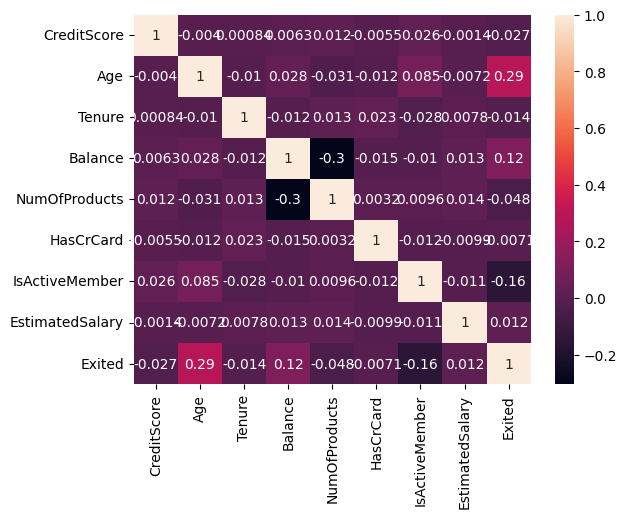

In [56]:
#Correlation Heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [57]:
df.value_counts('Gender')

,count
Gender,
Male,5457
Female,4543


In [58]:
#label encoding
df['Gender']=df['Gender'].map({'Female':0,'Male':1})

In [59]:
df.head(2)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,0,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0


In [60]:
df.value_counts('Geography')

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [61]:
#one hot encoding
df=pd.get_dummies(df,columns=['Geography'],drop_first=True)

In [62]:
df.head(2)

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True


In [63]:
df=df.astype(int)

In [64]:
df.head(2)

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0,1,1,1,101348,1,0,0
1,608,0,41,1,83807,1,0,1,112542,0,0,1


In [68]:
X=df.drop('Exited',axis=1)
y=df['Exited']

In [71]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [73]:
#Feature Scaling

#Important for:

#Logistic Regression
#KNN
#SVM
from sklearn.preprocessing import  StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [75]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [77]:
#Logistic Regression Model
lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

In [78]:
accuracy_score(y_test, y_pred)

0.811

In [79]:
confusion_matrix(y_test, y_pred)

array([[1543,   64],
       [ 314,   79]])

In [81]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



In [82]:
#Decision Tree Classifier
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [83]:
accuracy_score(y_test, y_pred_dt)

0.779

In [84]:
confusion_matrix(y_test, y_pred_dt)

array([[1359,  248],
       [ 194,  199]])

In [85]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.88      0.85      0.86      1607
           1       0.45      0.51      0.47       393

    accuracy                           0.78      2000
   macro avg       0.66      0.68      0.67      2000
weighted avg       0.79      0.78      0.78      2000



In [86]:
#Random Classifier Model
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [87]:
accuracy_score(y_test, y_pred_rf)

0.866

In [88]:
confusion_matrix(y_test, y_pred_rf)

array([[1546,   61],
       [ 207,  186]])

In [89]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.47      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000



In [91]:
importance = rf.feature_importances_

features = X.columns

feature_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

feature_df.sort_values(by='Importance', ascending=False)

,Feature,Importance
2,Age,0.238354
8,EstimatedSalary,0.147037
0,CreditScore,0.142946
4,Balance,0.140565
5,NumOfProducts,0.133386
3,Tenure,0.082187
7,IsActiveMember,0.038719
9,Geography_Germany,0.025907
6,HasCrCard,0.019055
1,Gender,0.018105


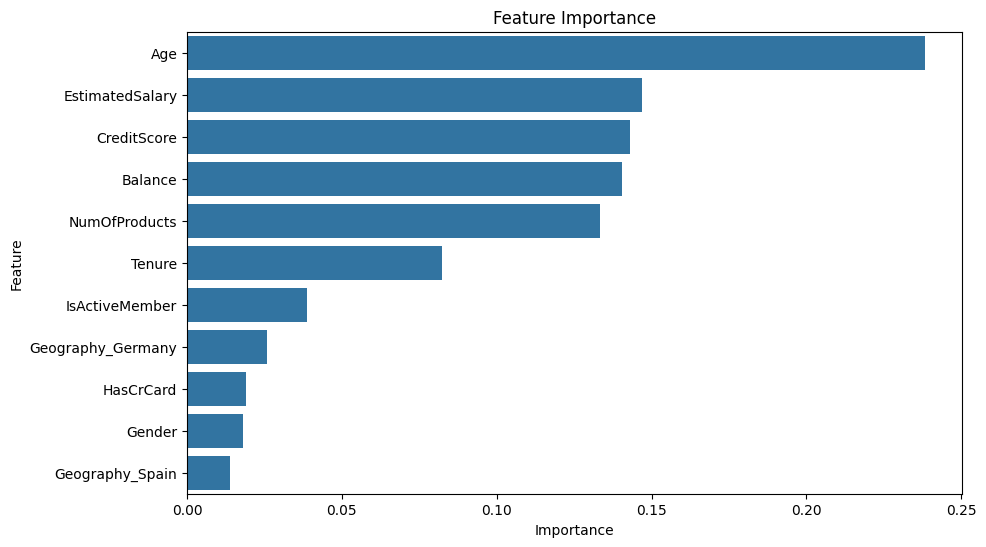

In [92]:
feature_df = feature_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_df
)

plt.title("Feature Importance")
plt.show()